#### Query: (hand or gripper) and (manipulation or grasping or grip or skill)  
#### Years: 2019-2025
#### Citation: 1+
#### Publisher: IEEE

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_dir = Path("data")
if not data_dir.is_dir():
    data_dir = Path("crawlers/IEEE-Xplore-API_p3/data")

files = sorted(
    data_dir.glob("data_*.json"),
    key=lambda path: int(path.stem.split("_")[-1]),
)
if not files:
    raise FileNotFoundError(f"No IEEE result files found in {data_dir.resolve()}")

all_articles_raw = []
for path in files:
    with path.open(encoding="utf-8") as file:
        response = json.load(file)
    all_articles_raw.extend(response.get("articles", []))

# IEEE article_number is the stable identifier. Deduplicate overlapping pages
# while retaining the first occurrence and falling back to title if needed.
articles_by_id = {}
for article in all_articles_raw:
    identifier = article.get("article_number") or article.get("title")
    articles_by_id.setdefault(str(identifier), article)
all_articles = list(articles_by_id.values())

print(f"Loaded {len(files)} pages")
print(f"Raw rows: {len(all_articles_raw)}")
print(f"Unique articles: {len(all_articles)}")

Loaded 33 pages
Raw rows: 6413
Unique articles: 6413


In [10]:
print("Overall Number of Articles: ",len(all_articles))

Overall Number of Articles:  6413


In [11]:
keywords_0 = ["hand", "gripper"]
keywords_1 = ["manipulation", "grasping", "grip", "skill"]

keywords_used = []
terms_used = []
articles_filtered = []
articles_filtered_titles = []
missing_index_terms = 0

for article in all_articles:
    try:
        citations = int(article.get("citing_paper_count", 0) or 0)
    except (TypeError, ValueError):
        citations = 0
    if citations <= 0:
        continue

    index_terms = article.get("index_terms")
    if not isinstance(index_terms, dict):
        missing_index_terms += 1
        continue

    all_terms = []
    for term_group in index_terms.values():
        if not isinstance(term_group, dict):
            continue
        all_terms.extend(
            str(term).lower() for term in term_group.get("terms", [])
        )
    all_terms = np.unique(all_terms)

    matched_keywords_0 = [
        keyword for keyword in keywords_0
        if any(keyword in term for term in all_terms)
    ]
    matched_keywords_1 = [
        keyword for keyword in keywords_1
        if any(keyword in term for term in all_terms)
    ]

    if matched_keywords_0 and matched_keywords_1:
        articles_filtered.append(article)
        articles_filtered_titles.append(article.get("title", ""))
        keywords_used.extend(matched_keywords_0 + matched_keywords_1)
        terms_used.extend(all_terms)

terms_used = np.unique(terms_used)
print(f"Skipped {missing_index_terms} cited articles without index terms")

Skipped 1807 cited articles without index terms


In [12]:
print("Overall filtered Articles: ",len(articles_filtered))

Overall filtered Articles:  2070


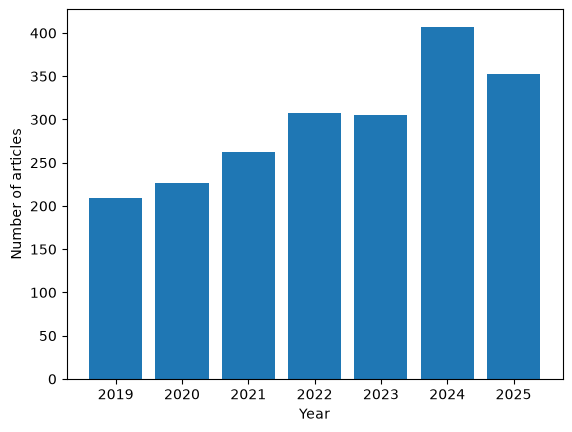

In [13]:
years=[]
for i in articles_filtered:
    years.append(i["publication_year"])
plt.bar(*np.unique(years, return_counts=True))
# set x-axis label
plt.xlabel('Year')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

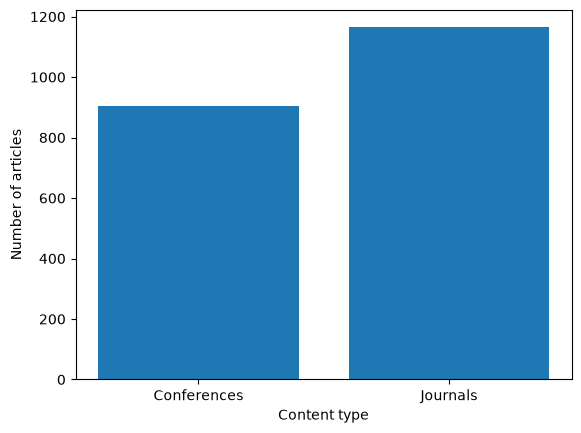

In [14]:
content_type=[]
for i in articles_filtered:
    content_type.append(i["content_type"].split()[0])
plt.bar(*np.unique(content_type, return_counts=True))
# set x-axis label
plt.xlabel('Content type')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

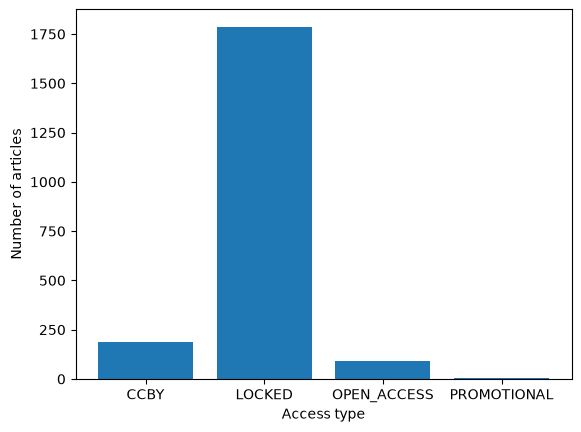

In [15]:
access_type=[]
for i in articles_filtered:
    access_type.append(i["access_type"].split()[0])
plt.bar(*np.unique(access_type, return_counts=True))
# set x-axis label
plt.xlabel('Access type')
# set y-axis label
plt.ylabel('Number of articles')
plt.show()

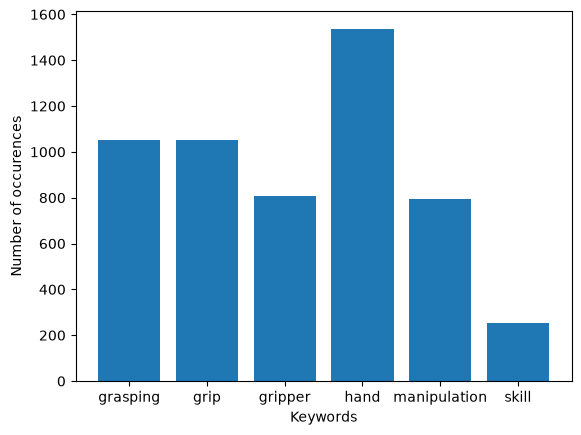

In [16]:
plt.bar(*np.unique(keywords_used, return_counts=True))
# set x-axis label
plt.xlabel('Keywords')
# set y-axis label
plt.ylabel('Number of occurences')
plt.show()